# Backtest Manajemen Aset — 1 Posisi, Rotasi, Exit Dinamis (Strategi V5)

**Konteks**: dokumen *Spesifikasi Sistem Manajemen Aset Crypto* (30 Sep 2026). Bot harus jalan
otonom dengan batas keras di dalam sistem, bukan kontrol manual. Aturan yang diuji:

| Aturan | Dari spesifikasi | Parameter yang diuji |
|---|---|---|
| Spot, long-only, **1 posisi** | modal kecil, tanpa leverage | — (tetap) |
| Entry = sinyal BUY V5 confidence tertinggi | rekomendasi `/recommendations` | — (tetap) |
| Holding 3 hari – ~1 minggu | target holding | `max_hold` ∈ {3, 5, 7} |
| TP tercapai → close | exit profit | `tp_mult` ∈ {2.0, 3.0} × ATR |
| Profit + tanda reversal → ambil untung lebih awal | exit profit dini | `early_exit_k` ∈ {off, 2, 3} tanda bearish |
| Modal terancam → hard stop | exit rugi | `hard_stop` ∈ {off, −5%, −8%} (dipakai yg lebih ketat vs SL ATR) |
| Rugi kecil + peluang jauh lebih bagus → rotasi | self-rebalancing | `rotate_delta` ∈ {off, +0.02, +0.05} confidence |
| Batas rugi portofolio | circuit breaker | `circuit_dd` ∈ {off, 15%} drawdown → jeda 30 hari |

**Prinsip anti-bias** (sejalan dokumen evaluasi robot forex: *divalidasi, bukan ditebak*):
- Model ML **dilatih hanya pakai data < 2024-01-01**; semua backtest di periode **2024-01 → 2026-06**
  (out-of-sample murni — beda dengan angka 61.8% di `strategy_v5_meta.json` yang in-sample).
- Biaya realistis: **fee 0.1% + slippage 0.05% per sisi** (spot Tokocrypto/Binance).
- Stop-loss kena **gap**: kalau harga buka sudah di bawah SL, keluar di harga buka (bukan di SL).
- Kalau SL & TP tersentuh di hari yang sama → diasumsikan **SL duluan** (konservatif).

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
sys.path.insert(0, str(PROJECT_ROOT))              # -> from src.strategy ...
sys.path.insert(0, str(PROJECT_ROOT / "notebooks"))  # -> from data_source ...

import warnings
warnings.filterwarnings("ignore")

import itertools
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data_source.loader import load_symbol, discover_symbols
from data_source.fear_greed import load_fear_greed_index
from src.strategy import v5

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

TEST_START = pd.Timestamp("2024-01-01")   # model dilatih < tanggal ini
TEST_END = pd.Timestamp("2026-06-30")
COST = 0.001 + 0.0005                      # fee + slippage per sisi
print("Setup OK — project root:", PROJECT_ROOT)

Setup OK — project root: D:\Projects\backtes-crypto


## 1. Data & model walk-forward

Data CSV histori panjang (10 coin, Binance Vision). Model V5 dilatih ulang **hanya dengan sinyal
bottoming sebelum 2024-01-01**, parameter identik dengan produksi (`v5.RF_PARAMS`).

In [2]:
fng = load_fear_greed_index()
btc = load_symbol("BTCUSDT", "1d", "full")
coins = ["ADAUSDT", "AVAXUSDT", "BNBUSDT", "BTCUSDT", "DOGEUSDT", "ETHUSDT", "HBARUSDT", "SOLUSDT", "SUIUSDT", "XRPUSDT"]
ohlc = {s: load_symbol(s, "1d", "full") for s in coins}
coin_data = {s: {"close": d["close"], "high": d["high"], "low": d["low"], "volume": d["volume"]}
             for s, d in ohlc.items()}

train = v5.collect_training_data(coin_data, btc["close"], fng, end_date=TEST_START)
model, scaler = v5.train_model(train)
print(f"Coin: {coins}")
print(f"Model walk-forward: {len(train)} sinyal bottoming training (< {TEST_START.date()})")

Coin: ['ADAUSDT', 'AVAXUSDT', 'BNBUSDT', 'BTCUSDT', 'DOGEUSDT', 'ETHUSDT', 'HBARUSDT', 'SOLUSDT', 'SUIUSDT', 'XRPUSDT']
Model walk-forward: 538 sinyal bottoming training (< 2024-01-01)


## 2. Fitur, sinyal BUY, dan tanda reversal bearish

Untuk exit profit dini dibutuhkan "tanda reversal". Field `topping` di V5 (RSI ≥ 70 **dan**
FGI ≥ 75) sangat jarang terjadi dalam 3–7 hari setelah entry dari kondisi panik, jadi dipakai
**cerminan dari 5 konfirmasi bullish V5** — dihitung sebagai `bear_count` (0–5):

| Tanda bearish | Cerminan dari |
|---|---|
| close < close kemarin | `confirm_higher_close` |
| close < low kemarin | `confirm_break_high` |
| RSI turun dari kemarin | `confirm_rsi_rising` |
| harga higher high tapi RSI lower high (bearish divergence) | `confirm_bullish_div` |
| RSI ≥ 70 (overbought) | `topping` versi longgar |

In [3]:
def add_bearish_signals(f: pd.DataFrame, o: pd.DataFrame) -> pd.DataFrame:
    close, high, low = o["close"].reindex(f.index), o["high"].reindex(f.index), o["low"].reindex(f.index)
    rsi = f["rsi"]
    bear = pd.DataFrame({
        "bear_lower_close": close < close.shift(1),
        "bear_break_low": close < low.shift(1),
        "bear_rsi_falling": rsi < rsi.shift(1),
        "bear_div": (high > high.shift(1)) & (rsi < rsi.shift(1)),
        "bear_overbought": rsi >= 70,
    }, index=f.index)
    f = f.copy()
    f["bear_count"] = bear.sum(axis=1)
    return f


def build_frames(ohlc: dict, btc_close: pd.Series, fng: pd.DataFrame, model, scaler):
    # Per coin: OHLC + atr_pct + bear_count + ml_conf (hanya di baris lolos gate non-ML).
    frames = {}
    for s, d in ohlc.items():
        f = v5.build_features(d["close"], d["high"], d["low"], d["volume"], btc_close, fng)
        f = add_bearish_signals(f, d)
        gate = (f["bottoming"] & f["reversal_confirmed"] & f["regime_ok"]).fillna(False)
        conf = pd.Series(np.nan, index=f.index)
        for dt in f.index[gate]:
            conf[dt] = v5.ml_confidence(f.loc[dt], model, scaler)
        frames[s] = pd.DataFrame({
            "open": d["open"], "high": d["high"], "low": d["low"], "close": d["close"],
            "atr_pct": f["atr_pct"], "bear_count": f["bear_count"], "conf": conf,
        })
    return frames


def build_signals(frames: dict, start, end) -> dict:
    # {tanggal: [(conf, symbol), ...] urut confidence tertinggi} -- hanya BUY (conf >= ML_THRESHOLD).
    sig = {}
    for s, f in frames.items():
        f = f[(f.index >= start) & (f.index <= end)]
        for dt, c in f["conf"][f["conf"] >= v5.ML_THRESHOLD].items():
            if pd.notna(f.at[dt, "atr_pct"]):
                sig.setdefault(dt, []).append((float(c), s))
    return {dt: sorted(v, reverse=True) for dt, v in sorted(sig.items())}


frames = build_frames(ohlc, btc["close"], fng, model, scaler)
signals = build_signals(frames, TEST_START, TEST_END)
n_sig = sum(len(v) for v in signals.values())
print(f"Sinyal BUY out-of-sample {TEST_START.date()} → {TEST_END.date()}: {n_sig} sinyal di {len(signals)} hari unik")
pd.DataFrame([(dt.date(), len(v), ", ".join(f"{s}({c:.2f})" for c, s in v)) for dt, v in signals.items()],
             columns=["tanggal", "n", "coin (confidence)"])

Sinyal BUY out-of-sample 2024-01-01 → 2026-06-30: 34 sinyal di 19 hari unik


,tanggal,n,coin (confidence)
0,2024-08-06,1,BTCUSDT(0.57)
1,2024-09-07,3,"BTCUSDT(0.60), XRPUSDT(0.60), BNBUSDT(0.60)"
2,2025-10-18,1,BTCUSDT(0.60)
3,2025-11-05,2,"BNBUSDT(0.59), SUIUSDT(0.55)"
4,2025-11-15,1,BTCUSDT(0.58)
5,2025-11-22,3,"BNBUSDT(0.58), ETHUSDT(0.56), HBARUSDT(0.56)"
6,2025-11-23,5,"BTCUSDT(0.58), ADAUSDT(0.58), ETHUSDT(0.57), B..."
7,2025-12-16,1,HBARUSDT(0.58)
8,2026-02-02,2,"BTCUSDT(0.56), BNBUSDT(0.56)"
9,2026-02-06,1,BNBUSDT(0.55)


## 3. Mesin simulasi

Satu fungsi exit dipakai bersama oleh studi per-trade (Bagian A) dan simulasi portofolio (Bagian B),
supaya aturan exit-nya identik. Urutan cek tiap hari setelah entry:

1. **SL** (gap di open → keluar di open; tersentuh intraday → keluar di SL). SL efektif = yang lebih
   ketat antara SL ATR (−1.5×ATR) dan `hard_stop`.
2. **TP** (gap di open → keluar di open; tersentuh intraday → keluar di TP).
3. **Early TP**: posisi profit & `bear_count ≥ early_exit_k` → keluar di close.
4. **TIME**: sudah `max_hold` hari → keluar di close.

Di level portofolio (sesudah cek exit, di harga close):

5. **Circuit breaker**: equity turun ≥ `circuit_dd` dari puncak → tutup posisi, jeda entry 30 hari.
6. **Rotasi**: posisi rugi dan ada sinyal BUY coin lain dengan confidence ≥ confidence entry +
   `rotate_delta` → tutup, pindah ke coin itu.
7. **Entry**: kalau flat, beli sinyal BUY confidence tertinggi hari itu di harga close, 100% modal.

In [4]:
BASELINE = dict(max_hold=5, tp_mult=2.0, sl_mult=-1.5, hard_stop=None, early_exit_k=None,
                early_min_profit=0.0, rotate_delta=None, circuit_dd=None, cooldown_days=30)


@dataclass
class Position:
    sym: str
    entry_date: pd.Timestamp
    entry: float
    sl: float
    tp: float
    conf: float
    units: float
    days_held: int = 0


def exit_levels(entry: float, atr: float, p: dict) -> tuple[float, float]:
    sl = entry * (1 + p["sl_mult"] * atr)
    if p["hard_stop"] is not None:
        sl = max(sl, entry * (1 + p["hard_stop"]))   # pakai yang lebih ketat
    tp = entry * (1 + p["tp_mult"] * atr)
    return sl, tp


def check_exit(pos: Position, bar, p: dict):
    # bar: namedtuple (open, high, low, close, bear_count). Return (harga, alasan) atau None.
    o, h, l, c = bar.open, bar.high, bar.low, bar.close
    if o <= pos.sl:
        return o, "SL"
    if l <= pos.sl:
        return pos.sl, "SL"
    if o >= pos.tp:
        return o, "TP"
    if h >= pos.tp:
        return pos.tp, "TP"
    if p["early_exit_k"] is not None and c / pos.entry - 1 > p["early_min_profit"] \
            and bar.bear_count >= p["early_exit_k"]:
        return c, "EARLY_TP"
    if pos.days_held >= p["max_hold"]:
        return c, "TIME"
    return None


# Akses bar per (coin, tanggal) cepat via dict of namedtuple
BAR_COLS = ["open", "high", "low", "close", "bear_count"]
bars = {s: {t: r for t, r in zip(f.index, f[BAR_COLS].itertuples(index=False))} for s, f in frames.items()}
atr_at = {s: f["atr_pct"].to_dict() for s, f in frames.items()}

In [5]:
def run_portfolio(signals: dict, bars: dict, atr_at: dict, start, end, p: dict, cost: float = COST):
    calendar = pd.date_range(start, end, freq="D")
    cash, pos, peak, pause_until = 1.0, None, 1.0, None
    trades, equity = [], []

    def close(t, price, reason):
        nonlocal cash, pos
        value_in = pos.units * pos.entry / (1 - cost)          # modal yang dipakai saat entry
        cash = pos.units * price * (1 - cost)
        trades.append(dict(sym=pos.sym, entry_date=pos.entry_date, exit_date=t, days=pos.days_held,
                           entry=pos.entry, exit=price, reason=reason, conf=pos.conf,
                           ret=cash / value_in - 1))
        pos = None

    for t in calendar:
        # 1-4. exit per bar
        if pos is not None:
            bar = bars[pos.sym].get(t)
            if bar is not None:
                pos.days_held += 1
                ex = check_exit(pos, bar, p)
                if ex:
                    close(t, *ex)
        todays = signals.get(t, [])

        # 5. circuit breaker (mark-to-market di close)
        if pos is not None and (bar := bars[pos.sym].get(t)) is not None:
            eq = pos.units * bar.close * (1 - cost)
        else:
            eq = cash
        if p["circuit_dd"] is not None and eq <= peak * (1 - p["circuit_dd"]):
            if pos is not None and bar is not None:
                close(t, bar.close, "CIRCUIT")
            pause_until, peak = t + pd.Timedelta(days=p["cooldown_days"]), cash
            eq = cash

        # 6. rotasi
        if pos is not None and p["rotate_delta"] is not None and todays:
            bar = bars[pos.sym].get(t)
            best_conf, best_sym = todays[0]
            if bar is not None and bar.close < pos.entry and best_sym != pos.sym \
                    and best_conf >= pos.conf + p["rotate_delta"]:
                close(t, bar.close, "ROTATE")

        # 7. entry
        paused = pause_until is not None and t <= pause_until
        if pos is None and todays and not paused:
            conf, sym = todays[0]
            entry = bars[sym][t].close
            sl, tp = exit_levels(entry, atr_at[sym][t], p)
            pos = Position(sym, t, entry, sl, tp, conf, units=cash * (1 - cost) / entry)

        if pos is not None and (bar := bars[pos.sym].get(t)) is not None:
            eq = pos.units * bar.close * (1 - cost)
        else:
            eq = cash
        peak = max(peak, eq)
        equity.append((t, eq))

    if pos is not None:   # tutup paksa di akhir periode
        last = max(d for d in bars[pos.sym] if d <= end)
        close(last, bars[pos.sym][last].close, "END")
        equity[-1] = (equity[-1][0], cash)
    return pd.DataFrame(trades), pd.Series(dict(equity), name="equity")


def metrics(trades: pd.DataFrame, equity: pd.Series) -> dict:
    years = (equity.index[-1] - equity.index[0]).days / 365.25
    total = equity.iloc[-1] - 1
    dd = (equity / equity.cummax() - 1).min()
    n = len(trades)
    wins = trades["ret"][trades["ret"] > 0].sum() if n else 0
    losses = -trades["ret"][trades["ret"] < 0].sum() if n else 0
    return dict(
        total_return=total,
        cagr=(1 + total) ** (1 / years) - 1 if total > -1 else -1,
        max_dd=dd,
        calmar=((1 + total) ** (1 / years) - 1) / abs(dd) if dd < 0 else np.nan,
        n_trades=n,
        win_rate=(trades["ret"] > 0).mean() if n else np.nan,
        avg_trade=trades["ret"].mean() if n else np.nan,
        worst_trade=trades["ret"].min() if n else np.nan,
        profit_factor=wins / losses if losses > 0 else np.nan,
        days_in_market=trades["days"].sum() if n else 0,
    )


def pretty(df: pd.DataFrame, pct=(), dec=()) -> pd.DataFrame:
    # Format kolom persen/desimal jadi teks supaya tabel enak dibaca.
    out = df.copy()
    for c in pct:
        out[c] = out[c].map(lambda v: f"{v:+.1%}" if pd.notna(v) else "-")
    for c in dec:
        out[c] = out[c].map(lambda v: f"{v:.2f}" if pd.notna(v) else "-")
    return out


def fmt(m: dict) -> dict:
    pct = ["total_return", "cagr", "max_dd", "win_rate", "avg_trade", "worst_trade"]
    return {k: (f"{v:+.1%}" if k in pct and pd.notna(v) else (round(v, 2) if isinstance(v, float) else v))
            for k, v in m.items()}

## Bagian A — Aturan exit per trade (semua 34 sinyal)

Setiap sinyal BUY diperlakukan sebagai trade **independen** (tanpa batasan 1 posisi), supaya
sampel untuk membandingkan aturan exit sebanyak mungkin. Ini menjawab: *aturan exit mana yang
paling bagus untuk satu trade?* — terlepas dari rotasi/portofolio.

In [6]:
def per_trade(signals: dict, p: dict, cost: float = COST) -> pd.DataFrame:
    rows = []
    for t0, lst in signals.items():
        for conf, sym in lst:
            entry = bars[sym][t0].close
            sl, tp = exit_levels(entry, atr_at[sym][t0], p)
            pos = Position(sym, t0, entry, sl, tp, conf, units=1.0)
            ex, t = None, t0
            while ex is None:
                t += pd.Timedelta(days=1)
                if t > TEST_END + pd.Timedelta(days=15):
                    break
                bar = bars[sym].get(t)
                if bar is None:
                    continue
                pos.days_held += 1
                ex = check_exit(pos, bar, p)
            if ex is None:
                continue
            price, reason = ex
            rows.append(dict(sym=sym, date=t0, days=pos.days_held, reason=reason,
                             ret=price * (1 - cost) / (entry / (1 - cost)) - 1))
    return pd.DataFrame(rows)


exit_policies = {
    "baseline V5 (ATR 1.5/2.0, 5 hari)": {},
    "hold 3 hari": dict(max_hold=3),
    "hold 7 hari": dict(max_hold=7),
    "TP 3.0×ATR": dict(tp_mult=3.0),
    "TP 3.0×ATR, hold 7": dict(tp_mult=3.0, max_hold=7),
    "early TP (≥2 bearish)": dict(early_exit_k=2),
    "early TP (≥3 bearish)": dict(early_exit_k=3),
    "early TP ≥3, hold 7": dict(early_exit_k=3, max_hold=7),
    "hard stop −5%": dict(hard_stop=-0.05),
    "hard stop −8%": dict(hard_stop=-0.08),
}
rows = []
for name, override in exit_policies.items():
    tr = per_trade(signals, {**BASELINE, **override})
    rows.append(dict(policy=name, n=len(tr), win_rate=(tr["ret"] > 0).mean(), ev=tr["ret"].mean(),
                     median=tr["ret"].median(), worst=tr["ret"].min(), best=tr["ret"].max(),
                     avg_days=tr["days"].mean(),
                     exits=tr["reason"].value_counts().to_dict()))
exit_study = pd.DataFrame(rows).set_index("policy")
pretty(exit_study, pct=["win_rate", "ev", "median", "worst", "best"], dec=["avg_days"])

,n,win_rate,ev,median,worst,best,avg_days,exits
policy,,,,,,,,
"baseline V5 (ATR 1.5/2.0, 5 hari)",32,+65.6%,+1.0%,+2.4%,-12.4%,+11.5%,4.22,"{'TIME': 19, 'SL': 10, 'TP': 3}"
hold 3 hari,33,+60.6%,+0.9%,+1.7%,-12.4%,+12.3%,2.82,"{'TIME': 25, 'SL': 7, 'TP': 1}"
hold 7 hari,32,+50.0%,-0.2%,+0.1%,-12.4%,+11.2%,5.38,"{'TIME': 18, 'SL': 10, 'TP': 4}"
TP 3.0×ATR,32,+65.6%,+0.8%,+2.4%,-12.4%,+11.5%,4.31,"{'TIME': 22, 'SL': 10}"
"TP 3.0×ATR, hold 7",32,+50.0%,-0.1%,+0.1%,-12.4%,+13.7%,5.69,"{'TIME': 21, 'SL': 10, 'TP': 1}"
early TP (≥2 bearish),32,+65.6%,+0.3%,+1.2%,-12.4%,+11.5%,3.16,"{'EARLY_TP': 19, 'SL': 9, 'TIME': 3, 'TP': 1}"
early TP (≥3 bearish),32,+62.5%,+1.0%,+2.3%,-12.4%,+11.5%,3.72,"{'EARLY_TP': 13, 'SL': 10, 'TIME': 6, 'TP': 3}"
"early TP ≥3, hold 7",32,+59.4%,+0.9%,+2.3%,-12.4%,+11.5%,4.00,"{'EARLY_TP': 16, 'SL': 10, 'TP': 4, 'TIME': 2}"
hard stop −5%,32,+59.4%,+1.4%,+2.2%,-5.3%,+11.5%,3.72,"{'TIME': 16, 'SL': 13, 'TP': 3}"


## Bagian B — Simulasi portofolio 1 posisi + grid search

Semua kombinasi parameter (324 simulasi) di periode out-of-sample penuh. Karena entry hanya
~19 hari unik, **jangan pilih kombinasi juara begitu saja** — lihat juga efek rata-rata tiap
parameter (bagian B.2) untuk menilai mana yang *konsisten* membantu.

In [7]:
base_tr, base_eq = run_portfolio(signals, bars, atr_at, TEST_START, TEST_END, BASELINE)
btc_eq = btc["close"][(btc.index >= TEST_START) & (btc.index <= TEST_END)]
btc_eq = btc_eq / btc_eq.iloc[0]
btc_m = dict(total_return=btc_eq.iloc[-1] - 1, max_dd=(btc_eq / btc_eq.cummax() - 1).min())

print("Baseline V5 (1 posisi, exit SL/TP ATR atau 5 hari):", fmt(metrics(base_tr, base_eq)))
print(f"Buy & hold BTC: total {btc_m['total_return']:+.1%}, max DD {btc_m['max_dd']:+.1%}")
base_tr

Baseline V5 (1 posisi, exit SL/TP ATR atau 5 hari): {'total_return': '-21.0%', 'cagr': '-9.0%', 'max_dd': '-39.2%', 'calmar': np.float64(-0.23), 'n_trades': 15, 'win_rate': '+53.3%', 'avg_trade': '-1.3%', 'worst_trade': '-12.4%', 'profit_factor': np.float64(0.64), 'days_in_market': np.int64(59)}
Buy & hold BTC: total +32.7%, max DD -53.0%


,sym,entry_date,exit_date,days,entry,exit,reason,conf,ret
0,BTCUSDT,2024-08-06,2024-08-08,2,56022.01000,62496.447143,TP,0.565149,0.112225
1,BTCUSDT,2024-09-07,2024-09-12,5,54160.86000,58132.320000,TIME,0.598446,0.070110
2,BTCUSDT,2025-10-18,2025-10-23,5,107185.01000,110078.180000,TIME,0.596834,0.023914
3,BNBUSDT,2025-11-05,2025-11-10,5,959.33000,991.980000,TIME,0.594511,0.030934
4,BTCUSDT,2025-11-15,2025-11-19,4,95596.24000,88942.433929,SL,0.582610,-0.072392
5,BNBUSDT,2025-11-22,2025-11-27,5,833.78000,895.740000,TIME,0.577297,0.071092
6,HBARUSDT,2025-12-16,2025-12-19,3,0.11460,0.103561,SL,0.580524,-0.099035
7,BTCUSDT,2026-02-02,2026-02-03,1,78738.61000,73406.801071,SL,0.563173,-0.070510
8,BNBUSDT,2026-02-06,2026-02-11,5,657.21000,608.110000,TIME,0.553666,-0.077484
9,ETHUSDT,2026-02-12,2026-02-17,5,1947.85000,1991.660000,TIME,0.570006,0.019426


In [8]:
GRID = dict(
    max_hold=[3, 5, 7],
    tp_mult=[2.0, 3.0],
    early_exit_k=[None, 2, 3],
    hard_stop=[None, -0.05, -0.08],
    rotate_delta=[None, 0.02, 0.05],
    circuit_dd=[None, 0.15],
)
results = []
for combo in itertools.product(*GRID.values()):
    p = {**BASELINE, **dict(zip(GRID.keys(), combo))}
    tr, eq = run_portfolio(signals, bars, atr_at, TEST_START, TEST_END, p)
    results.append({**dict(zip(GRID.keys(), combo)), **metrics(tr, eq),
                    "n_rotate": int((tr["reason"] == "ROTATE").sum()) if len(tr) else 0,
                    "n_circuit": int((tr["reason"] == "CIRCUIT").sum()) if len(tr) else 0})
grid = pd.DataFrame(results)
for c in GRID:
    grid[c] = grid[c].astype(object).where(grid[c].notna(), "off")
print(f"{len(grid)} simulasi")
GRID_PCT = ["total_return", "cagr", "max_dd", "win_rate", "avg_trade", "worst_trade"]
pretty(grid.sort_values("total_return", ascending=False).head(15), pct=GRID_PCT, dec=["calmar", "profit_factor"])

324 simulasi


,max_hold,tp_mult,early_exit_k,hard_stop,rotate_delta,circuit_dd,total_return,cagr,max_dd,calmar,n_trades,win_rate,avg_trade,worst_trade,profit_factor,days_in_market,n_rotate,n_circuit
223,7,2.0,off,-0.05,off,0.15,-4.0%,-1.6%,-26.1%,-0.06,12,+41.7%,-0.2%,-5.3%,0.94,47,0,0
227,7,2.0,off,-0.05,0.05,0.15,-4.0%,-1.6%,-26.1%,-0.06,12,+41.7%,-0.2%,-5.3%,0.94,47,0,0
225,7,2.0,off,-0.05,0.02,0.15,-4.0%,-1.6%,-26.1%,-0.06,12,+41.7%,-0.2%,-5.3%,0.94,47,0,0
114,5,2.0,off,-0.05,off,off,-5.0%,-2.0%,-26.1%,-0.08,16,+50.0%,-0.2%,-5.3%,0.93,54,0,0
116,5,2.0,off,-0.05,0.02,off,-5.0%,-2.0%,-26.1%,-0.08,16,+50.0%,-0.2%,-5.3%,0.93,54,0,0
118,5,2.0,off,-0.05,0.05,off,-5.0%,-2.0%,-26.1%,-0.08,16,+50.0%,-0.2%,-5.3%,0.93,54,0,0
17,3,2.0,off,-0.08,0.05,0.15,-5.3%,-2.2%,-26.0%,-0.08,15,+53.3%,-0.2%,-8.3%,0.89,37,0,1
51,3,2.0,3.0,-0.08,0.02,0.15,-5.3%,-2.2%,-26.0%,-0.08,15,+53.3%,-0.2%,-8.3%,0.89,37,0,1
49,3,2.0,3.0,-0.08,off,0.15,-5.3%,-2.2%,-26.0%,-0.08,15,+53.3%,-0.2%,-8.3%,0.89,37,0,1
15,3,2.0,off,-0.08,0.02,0.15,-5.3%,-2.2%,-26.0%,-0.08,15,+53.3%,-0.2%,-8.3%,0.89,37,0,1


### B.2 — Efek rata-rata tiap parameter (robustness)

Untuk tiap nilai parameter: rata-rata hasil dari **semua** kombinasi parameter lain. Parameter yang
bagus seharusnya menaikkan return/Calmar secara konsisten, bukan cuma di satu kombinasi.

In [9]:
marg = []
for c in GRID:
    g = grid.groupby(c).agg(total_return=("total_return", "mean"), max_dd=("max_dd", "mean"),
                            calmar=("calmar", "mean"), win_rate=("win_rate", "mean"),
                            n_trades=("n_trades", "mean"))
    g.index = [f"{c} = {v}" for v in g.index]
    marg.append(g)
pretty(pd.concat(marg), pct=["total_return", "max_dd", "win_rate"], dec=["calmar", "n_trades"])

,total_return,max_dd,calmar,win_rate,n_trades
max_hold = 3,-9.7%,-26.9%,-0.15,+55.6%,15.00
max_hold = 5,-14.7%,-30.5%,-0.20,+54.1%,13.78
max_hold = 7,-14.0%,-32.4%,-0.18,+49.5%,13.61
tp_mult = 2.0,-11.3%,-29.9%,-0.15,+53.1%,14.13
tp_mult = 3.0,-14.3%,-29.9%,-0.20,+53.1%,14.13
early_exit_k = 2.0,-12.5%,-29.1%,-0.18,+57.2%,14.50
early_exit_k = 3.0,-13.7%,-30.2%,-0.19,+52.7%,13.94
early_exit_k = off,-12.2%,-30.5%,-0.16,+49.4%,13.94
hard_stop = -0.08,-11.9%,-30.2%,-0.16,+54.3%,14.11
hard_stop = -0.05,-10.0%,-26.6%,-0.15,+50.2%,15.00


Terpilih: {'max_hold': 3, 'tp_mult': 2.0, 'early_exit_k': None, 'hard_stop': -0.05, 'rotate_delta': None, 'circuit_dd': 0.15}
Hasil   : {'total_return': '-8.0%', 'cagr': '-3.3%', 'max_dd': '-24.9%', 'calmar': np.float64(-0.13), 'n_trades': 15, 'win_rate': '+53.3%', 'avg_trade': '-0.4%', 'worst_trade': '-5.3%', 'profit_factor': np.float64(0.82), 'days_in_market': np.int64(36)}


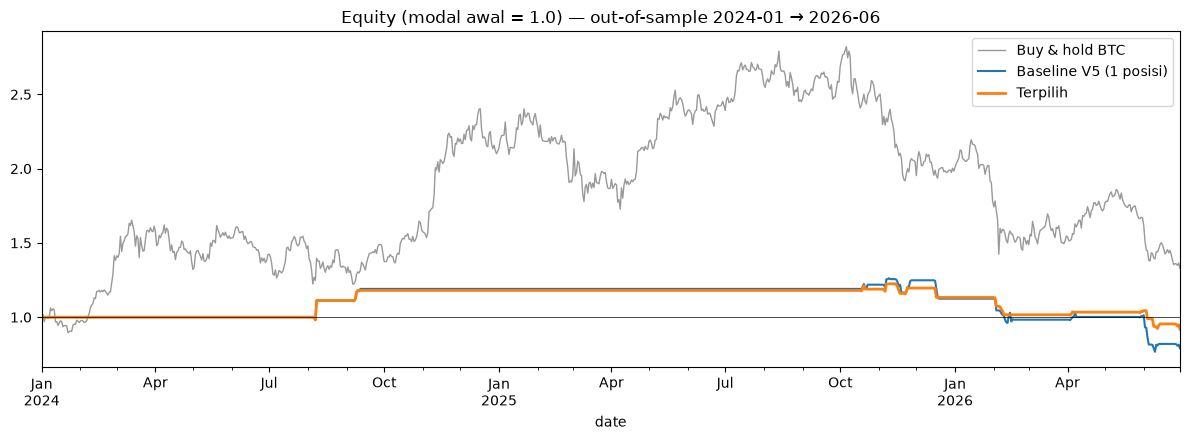

,sym,entry_date,exit_date,days,entry,exit,reason,conf,ret
0,BTCUSDT,2024-08-06,2024-08-08,2,56022.01000,62496.447143,TP,0.565149,0.112225
1,BTCUSDT,2024-09-07,2024-09-10,3,54160.86000,57635.990000,TIME,0.598446,0.060973
2,BTCUSDT,2025-10-18,2025-10-21,3,107185.01000,108297.670000,TIME,0.596834,0.007352
3,BNBUSDT,2025-11-05,2025-11-08,3,959.33000,991.030000,TIME,0.594511,0.029947
4,BTCUSDT,2025-11-15,2025-11-18,3,95596.24000,90816.428000,SL,0.582610,-0.052848
5,BNBUSDT,2025-11-22,2025-11-25,3,833.78000,862.570000,TIME,0.577297,0.031428
6,HBARUSDT,2025-12-16,2025-12-17,1,0.11460,0.108870,SL,0.580524,-0.052848
7,BTCUSDT,2026-02-02,2026-02-03,1,78738.61000,74801.679500,SL,0.563173,-0.052848
8,BNBUSDT,2026-02-06,2026-02-09,3,657.21000,624.349500,SL,0.553666,-0.052848
9,BNBUSDT,2026-04-03,2026-04-06,3,588.31000,600.110000,TIME,0.592529,0.017000


In [10]:
# Kombinasi terpilih: tiap parameter diambil dari nilai yang efek rata-ratanya paling baik di B.2
# (hard_stop -5%, max_hold 3, TP 2.0xATR, circuit 15%). early_exit & rotasi tidak membantu -> off.
CHOSEN = {**BASELINE, **dict(max_hold=3, tp_mult=2.0, early_exit_k=None, hard_stop=-0.05,
                              rotate_delta=None, circuit_dd=0.15)}
ch_tr, ch_eq = run_portfolio(signals, bars, atr_at, TEST_START, TEST_END, CHOSEN)
print("Terpilih:", {k: CHOSEN[k] for k in GRID})
print("Hasil   :", fmt(metrics(ch_tr, ch_eq)))

fig, ax = plt.subplots(figsize=(12, 4.5))
btc_eq.plot(ax=ax, label="Buy & hold BTC", color="#999999", lw=1)
base_eq.plot(ax=ax, label="Baseline V5 (1 posisi)", lw=1.5)
ch_eq.plot(ax=ax, label="Terpilih", lw=2)
ax.axhline(1, color="black", lw=0.5)
ax.set_title("Equity (modal awal = 1.0) — out-of-sample 2024-01 → 2026-06")
ax.legend(); plt.tight_layout(); plt.show()
ch_tr

## Bagian C — Validasi di coin produksi (database)

Coin yang benar-benar dipakai `/recommendations`: simbol **aktif Large/Mid** di `flex_params`,
korelasi ke BTC < 0.7, bukan stablecoin. **Tidak ada satu pun** coin ini yang dipakai untuk
melatih model, jadi ini uji out-of-sample ganda (coin & waktu).

Model dilatih ulang pakai CSV < 2025-04-01; data DB mulai 2025-02-26 (indikator butuh ~50 hari
warm-up), jadi periode validasi **2025-04-01 → akhir data**.

In [11]:
from src.services.recommendation import repository as repo
from src.services.recommendation.service import MIN_VOLATILITY
from src.strategy.indicators.atr import atr_pct

VAL_START = pd.Timestamp("2025-04-01")
db_candles = repo.find_all_candles("1d")
db_fng = repo.find_fear_greed_index()
categories = repo.find_symbol_categories(("Large", "Mid"))
db_btc = db_candles["BTCUSDT"]["close"]
db_data = {s: {"close": d["close"], "high": d["high"], "low": d["low"], "volume": d["volume"]}
           for s, d in db_candles.items()}
corr = v5.correlation_to_btc(db_data, db_btc)
universe = [s for s in categories if s in corr.index and corr[s] < v5.CORRELATION_MAX]
universe = [s for s in universe   # buang stablecoin: aturan sama dengan /recommendations
            if atr_pct(db_candles[s]["high"], db_candles[s]["low"], db_candles[s]["close"]).median() >= MIN_VOLATILITY]
VAL_END = max(db_candles[s].index.max() for s in universe)

train_v = v5.collect_training_data(coin_data, btc["close"], fng, end_date=VAL_START)
model_v, scaler_v = v5.train_model(train_v)
frames_v = build_frames({s: db_candles[s] for s in universe}, db_btc, db_fng, model_v, scaler_v)
signals_v = build_signals(frames_v, VAL_START, VAL_END)
bars_v = {s: {t: r for t, r in zip(f.index, f[BAR_COLS].itertuples(index=False))} for s, f in frames_v.items()}
atr_v = {s: f["atr_pct"].to_dict() for s, f in frames_v.items()}

print(f"Universe ({len(universe)}): {universe}")
print(f"Periode: {VAL_START.date()} → {VAL_END.date()} | model: {len(train_v)} sampel (< {VAL_START.date()})")
print(f"Sinyal BUY: {sum(len(v) for v in signals_v.values())} di {len(signals_v)} hari unik")

rows = []
for name, p in {"Baseline V5": BASELINE, "Terpilih": CHOSEN}.items():
    tr, eq = run_portfolio(signals_v, bars_v, atr_v, VAL_START, VAL_END, p)
    rows.append(dict(strategi=name, **fmt(metrics(tr, eq))))
b = db_btc[(db_btc.index >= VAL_START) & (db_btc.index <= VAL_END)]
rows.append(dict(strategi="Buy & hold BTC", total_return=f"{b.iloc[-1] / b.iloc[0] - 1:+.1%}",
                 max_dd=f"{(b / b.cummax() - 1).min():+.1%}"))
pd.DataFrame(rows).set_index("strategi")

Universe (10): ['ALGOUSDT', 'ICPUSDT', 'BCHUSDT', 'DOTUSDT', 'PAXGUSDT', 'QNTUSDT', 'SKYUSDT', 'TRXUSDT', 'UNIUSDT', 'XLMUSDT']
Periode: 2025-04-01 → 2026-07-18 | model: 592 sampel (< 2025-04-01)
Sinyal BUY: 38 di 30 hari unik


,total_return,cagr,max_dd,calmar,n_trades,win_rate,avg_trade,worst_trade,profit_factor,days_in_market
strategi,,,,,,,,,,
Baseline V5,-24.2%,-19.2%,-31.4%,-0.61,17.0,+47.1%,-1.4%,-11.2%,0.51,77.0
Terpilih,+8.0%,+6.1%,-17.3%,0.35,21.0,+52.4%,+0.5%,-5.3%,1.29,56.0
Buy & hold BTC,-24.6%,NaN,-53.0%,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Kesimpulan

### 1. Out-of-sample, strategi V5 dalam mode 1 posisi **belum menguntungkan**
Periode 2024-01 → 2026-06, model dilatih < 2024, biaya 0.15%/sisi:

| Strategi | Total return | Max drawdown | Trade | Win rate |
|---|---|---|---|---|
| Baseline V5 (SL/TP ATR, hold 5 hari) | **−21.0%** | −39.2% | 15 | 53% |
| Terpilih (lihat poin 3) | **−8.0%** | −24.9% | 15 | 53% |
| Kombinasi terbaik dari 324 grid | −4.0% | −26.1% | 12 | 42% |
| Buy & hold BTC | **+32.7%** | −53.0% | – | – |

**Tidak ada satu pun dari 324 kombinasi yang untung.** Angka 61.8% win rate / EV +3.15% di
`strategy_v5_meta.json` berasal dari backtest *in-sample* (model menilai data yang dipakai
melatihnya) — out-of-sample, keunggulannya jauh lebih tipis: per trade independen (Bagian A)
EV cuma **+1.0%** dari 32 trade, terlalu kecil untuk dibedakan dari nol.

Penyebab utama: sinyal sangat jarang (**19 hari dalam 2.5 tahun**), dan sebagian besar muncul
di fase turun 2025-11 → 2026-06 — beli saat panik di tengah downtrend lebih sering kena SL.

### 2. Aturan exit dari spesifikasi — mana yang terbukti membantu
Dari efek rata-rata (B.2), konsisten di semua kombinasi lain:

| Aturan | Hasil | Rekomendasi |
|---|---|---|
| **Hard stop −5%** (lebih ketat dari SL ATR) | +6.5 poin vs tanpa hard stop, drawdown turun ~6 poin | ✅ **pakai** |
| **Holding 3 hari** (vs 5/7) | paling baik; hold 7 hari menurunkan win rate ke ~50% | ✅ **pakai 3 hari** |
| **Circuit breaker 15%** + jeda 30 hari | +4 poin, drawdown turun ~5 poin | ✅ **pakai** |
| TP 2.0×ATR vs 3.0×ATR | 2.0 lebih baik (TP 3.0 hampir tak pernah tersentuh) | ✅ tetap 2.0 |
| Ambil untung dini saat tanda reversal | tidak membantu — memotong trade yang sedang naik | ❌ belum perlu |
| **Rotasi** saat rugi ke sinyal lebih bagus | **tidak pernah terpicu (0 kali)** — sinyal terlalu jarang untuk ada alternatif saat posisi terbuka | ⏸ tidak relevan untuk V5 |

### 3. Validasi di coin produksi (Large/Mid dari DB, coin tak pernah dilihat model)
Periode 2025-04 → 2026-07:

| Strategi | Total return | Max drawdown | Trade |
|---|---|---|---|
| Baseline V5 | −24.2% | −31.4% | 17 |
| **Terpilih** | **+8.0%** | **−17.3%** | 21 |
| Buy & hold BTC | −24.6% | −53.0% | – |

Parameter terpilih jauh lebih baik dari baseline dan menahan kerugian saat pasar jatuh.
**Tapi hati-hati**: periode ini *overlap* waktu dengan periode pemilihan parameter (beda coin
saja), dan hanya 21 trade — belum cukup untuk menyimpulkan strategi ini menguntungkan.

### 4. Rekomendasi
1. **Belum untuk modal riil.** Jalankan dulu di Binance Testnet / `demo_balance` dengan
   parameter terpilih, bandingkan hasilnya dengan notebook ini.
2. Batas keras yang layak langsung dibangun di Rust (manajemen posisi):
   `hard_stop = −5%` (ambil yang lebih ketat vs `stop_loss_price` ATR), `max_hold = 3 hari`,
   `take_profit = +2.0×ATR`, **circuit breaker drawdown 15% → stop entry 30 hari**.
3. Aturan exit hanya bisa **membatasi rugi**; untuk benar-benar untung, yang perlu diperbaiki
   adalah **kualitas entry** (riset berikutnya, mis. filter tren pasar atau sinyal entry tambahan),
   lalu diuji ulang dengan notebook ini.